In [6]:
import numpy as np
import xarray as xr
from datetime import datetime , timedelta
import matplotlib.pyplot as plt
import netCDF4
# from weatherbenchX.metrics import probabilistic
# import apache_beam as beam
import logging
import os
# from weatherbenchX.data_loaders import xarray_loaders
# from weatherbenchX import aggregation, weighting, binning, beam_pipeline

In [2]:
# Start and end dates
start = datetime(2018, 1, 1, 0, 0)
end = datetime(2018, 12, 31, 23, 59)  # Adjust as needed

# Interval of 6 hours
interval = timedelta(hours=6)

# Generate timestamps
timestamps = []
current = start
while current <= end:
    timestamps.append(current.strftime('%Y%m%d%H'))
    current += interval

# Print or use the timestamps
for ts in timestamps:
    print(ts)

2018010100
2018010106
2018010112
2018010118
2018010200
2018010206
2018010212
2018010218
2018010300
2018010306
2018010312
2018010318
2018010400
2018010406
2018010412
2018010418
2018010500
2018010506
2018010512
2018010518
2018010600
2018010606
2018010612
2018010618
2018010700
2018010706
2018010712
2018010718
2018010800
2018010806
2018010812
2018010818
2018010900
2018010906
2018010912
2018010918
2018011000
2018011006
2018011012
2018011018
2018011100
2018011106
2018011112
2018011118
2018011200
2018011206
2018011212
2018011218
2018011300
2018011306
2018011312
2018011318
2018011400
2018011406
2018011412
2018011418
2018011500
2018011506
2018011512
2018011518
2018011600
2018011606
2018011612
2018011618
2018011700
2018011706
2018011712
2018011718
2018011800
2018011806
2018011812
2018011818
2018011900
2018011906
2018011912
2018011918
2018012000
2018012006
2018012012
2018012018
2018012100
2018012106
2018012112
2018012118
2018012200
2018012206
2018012212
2018012218
2018012300
2018012306
2018012312

In [6]:
obs = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/2018_180x360.nc")

In [7]:
def preprocess(ds):
    ens = np.int32(ds.encoding["source"].split("/")[-1].split(".")[0].split("_")[-1])
    ds = ds.expand_dims(dim={"number": [ens]})
    ds = ds.rename({"time":"prediction_timedelta"})
    ds = ds.expand_dims(dim={"time": [ds["prediction_timedelta"][0].values]})
    ds["prediction_timedelta"] = np.arange(0, 24*len(ds["prediction_timedelta"]), 24).astype("timedelta64[h]").astype("timedelta64[ns]")
    return ds

In [8]:
file = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_45step_2018011800_ens_*.nc"
ds = xr.open_mfdataset(file,chunks={}, engine='netcdf4', preprocess=preprocess)


In [9]:
ds

<xarray.Dataset> Size: 34GB
Dimensions:                                (time: 1, number: 30,
                                            prediction_timedelta: 46,
                                            latitude: 180, longitude: 360,
                                            level: 17)
Coordinates:
  * time                                   (time) datetime64[ns] 8B 2018-01-18
  * number                                 (number) int32 120B 0 1 2 ... 28 29
  * prediction_timedelta                   (prediction_timedelta) timedelta64[ns] 368B ...
  * level                                  (level) float32 68B 5.0 ... 1e+03
  * latitude                               (latitude) float32 720B -89.5 ... ...
  * longitude                              (longitude) float32 1kB 0.0 ... 359.0
Data variables: (12/16)
    2m_temperature                         (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
    10m_u_component_of_wind                (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
    10m_v_component_of_wind                (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
    mean_sea_level_pressure                (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
    surface_pressure                       (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
    volumetric_soil_water_layer_1          (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
    ...                                     ...
    u_component_of_wind                    (time, number, prediction_timedelta, level, latitude, longitude) float32 6GB dask.array<chunksize=(1, 1, 46, 17, 180, 360), meta=np.ndarray>
    v_component_of_wind                    (time, number, prediction_timedelta, level, latitude, longitude) float32 6GB dask.array<chunksize=(1, 1, 46, 17, 180, 360), meta=np.ndarray>
    specific_humidity                      (time, number, prediction_timedelta, level, latitude, longitude) float32 6GB dask.array<chunksize=(1, 1, 46, 17, 180, 360), meta=np.ndarray>
    geopotential                           (time, number, prediction_timedelta, level, latitude, longitude) float32 6GB dask.array<chunksize=(1, 1, 46, 17, 180, 360), meta=np.ndarray>
    total_precipitation_24hr               (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
    mean_top_net_long_wave_radiation_flux  (time, number, prediction_timedelta, latitude, longitude) float32 358MB dask.array<chunksize=(1, 1, 46, 180, 360), meta=np.ndarray>
Attributes:
    description:  Prediction from pangu_plasim model run 1

In [10]:
import xarray as xr
import numpy as np

# ---- helpers ----
def _detect_member_dim(da, prefer=None):
    if prefer and prefer in da.dims:
        return prefer
    for cand in ("number", "member", "ens", "realization", "ensemble"):
        if cand in da.dims:
            return cand
    raise ValueError("Could not detect ensemble member dim; pass member_dim.")

def _crps_skill_vec(targets, preds, member_dim):
    # E|X - y| over ensemble members
    return np.abs(preds - targets).mean(dim=member_dim, skipna=False)

def _sort_along_dim(da: xr.DataArray, dim: str) -> xr.DataArray:
    """Sort values along `dim` using the data (not the coord labels)."""
    return xr.apply_ufunc(
        np.sort,
        da,
        input_core_dims=[[dim]],
        output_core_dims=[[dim]],
        dask="parallelized",
        vectorize=False,
    )
def _mean_pair_abs_diff_fast(preds: xr.DataArray, member_dim: str) -> xr.DataArray:
    """
    E|X - X'| over ordered pairs via order stats:
    (2 / [n(n-1)]) * sum_k (2k - n - 1) X_(k), with X_(k) sorted along `member_dim`.
    """
    n = preds.sizes[member_dim]
    if n < 2:
        return xr.zeros_like(preds.isel({member_dim: 0}, drop=True))

    # IMPORTANT: member axis must be one dask chunk for performance/correctness.
    preds_sorted = _sort_along_dim(preds, member_dim)

    w = xr.DataArray(2 * np.arange(1, n + 1) - n - 1, dims=(member_dim,))
    S = (preds_sorted * w).sum(dim=member_dim, skipna=False)
    return (2.0 / (n * (n - 1))) * S

def _crps_ensemble_vec(targets, preds, member_dim):
    # CRPS = E|X - y| - 0.5 * E|X - X'|
    return _crps_skill_vec(targets, preds, member_dim) - 0.5 * _mean_pair_abs_diff_fast(preds, member_dim)

# ---- main: fully vectorized across all leads ----
def evaluate_crps_fast(
    forecast: xr.Dataset,
    analysis: xr.Dataset,
    var: str = "2m_temperature",
    *,
    time_dim: str = "time",
    lead_dim: str = "prediction_timedelta",
    member_dim: str | None = None,
    compute: bool = False,
):
    """
    Returns:
      Dataset with:
        - crps : DataArray, same dims as the input forecast minus member_dim
        - ssr  : DataArray, aggregated by lead only (variance-form spread–skill ratio)
    Notes:
      * 'ssr' is computed as sqrt(mean(spread^2) / mean(error^2)) where
        spread = ensemble std (ddof=1) and error = (ensemble_mean - target).
      * The mean() above is over all dims except 'lead_dim' (and of course excluding member_dim).
    """
    if var not in forecast or var not in analysis:
        raise KeyError(f"'{var}' must exist in both forecast and analysis.")

    f = forecast[var]
    mdim = _detect_member_dim(f, member_dim)

    # 1) Build valid_time and attach as a coord (fixed)
    valid_time = forecast[time_dim] + forecast[lead_dim]   # DataArray (time, lead)
    f = f.assign_coords(valid_time=valid_time)

    # 2) Vectorized selection of targets at those valid times
    t = analysis[var].sel({time_dim: f["valid_time"]})

    # 3) CRPS with O(n log n) spread term
    crps = _crps_ensemble_vec(t, f, mdim)
    crps.name = "crps"

    # 4) Spread–skill ratio (variance-form), aggregated by lead
    nmem = f.sizes[mdim]
    if nmem > 1:
        spread = f.std(dim=mdim, ddof=1, skipna=False)
    else:
        # with a single member, define spread=0 to avoid NaNs
        spread = xr.zeros_like(f.isel({mdim: 0}, drop=True))

    ens_mean = f.mean(dim=mdim, skipna=False)
    err2 = (ens_mean - t) ** 2

    # reduce over all non-lead, non-member dims (time, lat, lon, etc.)
    reduce_dims = [d for d in f.dims if d not in (lead_dim, mdim)]
    spread2_mean = (spread ** 2).mean(dim=reduce_dims, skipna=False) if reduce_dims else (spread ** 2)
    err2_mean = err2.mean(dim=reduce_dims, skipna=False) if reduce_dims else err2

    ssr = np.sqrt(spread2_mean / err2_mean)
    ssr.name = "ssr"

    out = xr.Dataset({"crps": crps, "ssr": ssr})
    return out.compute() if compute else out
# # ---- performance tips / recommended chunking ----
# def recommend_chunks(ds, member_dim="number", lead_dim="prediction_timedelta", space_hint=("latitude","longitude")):
#     """
#     Reasonable starting point: keep the *entire* ensemble in one chunk,
#     keep small lead chunks to reduce sort memory, and use moderate spatial chunks.
#     """
#     chunks = {member_dim: -1}  # whole member axis in one chunk -> required for fast sort
#     if lead_dim in ds.dims:
#         chunks[lead_dim] = 1     # tiny lead chunks; sorting memory scales with chunk size
#     for d in space_hint:
#         if d in ds.dims:
#             chunks[d] = 256      # tune for your FS / cluster
#     if "time" in ds.dims:
#         chunks["time"] = 32
#     return ds.chunk(chunks)

# ---- example usage ----
era5 = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/2018_180x360.nc",chunks={})
# ifs = xr.open_zarr("/scratch/10000/amarchakitus/test_ens/ifs_ens_2m_temperature.zarr", chunks={}, decode_timedelta=True)
# ifs  = recommend_chunks(ifs, member_dim="number")  # important for sort performance
files = [f"/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_45step_201801{day}00_ens_{ens}.nc" for day in range(14, 18) for ens in range(0, 11)]
#file = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_45step_2018011800_ens_*.nc"
ds = xr.open_mfdataset(files, chunks = {}, engine='netcdf4', preprocess=preprocess)
ds = ds[["2m_temperature"]].chunk({"time":1, "number":-1, "prediction_timedelta":1, "latitude":-1, "longitude":-1})

In [29]:
ds["2m_temperature"].values[0][5]

array([[[252.46873, 252.46419, 252.46063, ..., 252.51193, 252.4974 ,
         252.48227],
        [251.10472, 251.10449, 251.10428, ..., 251.0928 , 251.0973 ,
         251.10071],
        [249.53793, 249.5073 , 249.47668, ..., 249.57776, 249.56749,
         249.5556 ],
        ...,
        [252.05687, 252.15422, 252.24094, ..., 251.76343, 251.86188,
         251.95825],
        [247.5817 , 247.6062 , 247.62769, ..., 247.4884 , 247.52312,
         247.55363],
        [244.85812, 244.85626, 244.85431, ..., 244.86436, 244.86281,
         244.86089]],

       [[247.5331 , 247.57448, 247.90556, ..., 247.8021 , 247.67795,
         247.2641 ],
        [247.7814 , 247.96764, 247.65726, ..., 248.3194 , 247.82278,
         247.59517],
        [248.38148, 248.3401 , 248.19525, ..., 248.79533, 248.38148,
         248.17456],
        ...,
        [253.76149, 253.90634, 253.57526, ..., 253.12003, 253.26488,
         253.30626],
        [250.67833, 250.45071, 250.43002, ..., 250.03687, 250.43002,
   

In [12]:
era5 = era5.rename({"lat":"latitude", "lon":"longitude"})

In [13]:
res  = evaluate_crps_fast(ds, era5, var="2m_temperature", compute=True)
# Aggregate by lead 
# by_lead = res.crps.mean(dim=[d for d in res.crps.dims if d not in ("prediction_timedelta",)])
# for lead_td, val in zip(by_lead.prediction_timedelta.values, by_lead.values):
#     hrs = int(np.round(lead_td / np.timedelta64(1, "h")))
#     print(f"Step {hrs} hours: SSR {val:.4f}")

In [30]:
res["ssr"]

<xarray.DataArray 'ssr' (prediction_timedelta: 46)> Size: 184B
array([1.134401  , 0.40685678, 0.35173398, 0.31492144, 0.29630867,
       0.3030298 , 0.33196732, 0.37801152, 0.43391162, 0.48521703,
       0.5081849 , 0.5318736 , 0.5632182 , 0.5971891 , 0.61343104,
       0.6227169 , 0.6136645 , 0.5874889 , 0.5756427 , 0.5645259 ,
       0.5581048 , 0.5577959 , 0.574334  , 0.58662826, 0.5907775 ,
       0.58182913, 0.5657876 , 0.56202656, 0.56008   , 0.5554309 ,
       0.54415256, 0.5371447 , 0.52373224, 0.50856495, 0.50452805,
       0.49934885, 0.48660657, 0.4853912 , 0.49129027, 0.49147397,
       0.4927752 , 0.4970151 , 0.5044394 , 0.5212038 , 0.5455261 ,
       0.55110717], dtype=float32)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 368B 0 days ...

In [43]:
res["ssr"][0].shape

(46, 180, 360)

In [6]:
ens_mean = []
for ts_idx in range(len(timestamps)): #
    ts = timestamps[ts_idx]
    file_base = "/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_45step_{}_ens_*.nc".format(ts)
    ds = xr.open_mfdataset(file_base,combine="nested", concat_dim="number")
    fcst = ds["2m_temperature"].mean(dim="number")
    times = np.arange(0, len(ds.time) * 24, 24, dtype='timedelta64[h]').astype('timedelta64[ns]')
    ds_start_time = ds["time"][0].values
    ds_end_time = ds["time"][-1].values
    obs_ens = obs.sel(time=ds.time)["2m_temperature"]
    print("fcst shape:", fcst.shape)
    rmse_times = []
    for time in range(fcst.shape[0]):
        diff = (fcst[time] - obs_ens[time])
        sqr = diff ** 2
        mse = np.mean(sqr)
        rmse = np.sqrt(mse)
        rmse_times.append(float(rmse.values))
        #rmse = np.sqrt(np.mean(( np.array(fcst),np.array(obs_ens))** 2))
    ens_mean.append(rmse_times)
    


fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
fcst shape: (46, 180, 360)
f

OSError: [Errno -101] NetCDF: HDF error: '/project/pedramh/bing/PanguWeather/v2.0/HPC_scripts/results/S2S/1/predictions/pangu_plasim_1_24h_45step_2018061100_ens_2.nc'

In [ ]:
rmse_ens = np.array(ens_mean).mean(axis=0)

/home/gongbing/ipykernel_3629083/666182358.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


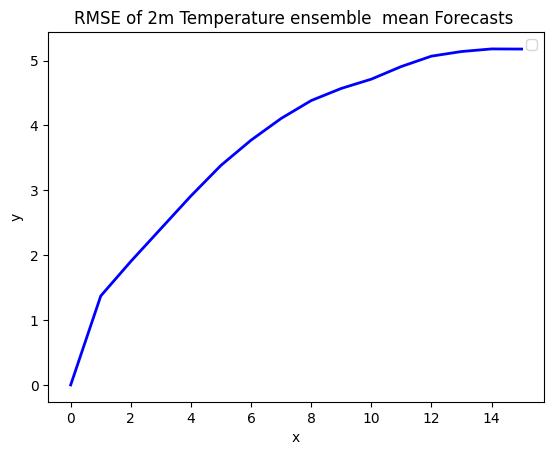

In [ ]:
import matplotlib.pyplot as plt

# Example data
x = list(range(0, 45))
y = rmse_ens

# Create the plot
plt.plot(x, y, color="blue", linewidth=2)

# Add labels and title
plt.xlabel("x")
plt.ylabel("y")
plt.title("RMSE of 2m Temperature ensemble  mean Forecasts ")

# Show legend
plt.legend()

# Display the plot
plt.show()

<xarray.Dataset> Size: 378MB
Dimensions:         (time: 1460, lat: 180, lon: 360)
Coordinates:
  * time            (time) datetime64[ns] 12kB 2018-01-01 ... 2018-12-31T18:0...
  * lon             (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
Data variables:
    2m_temperature  (time, lat, lon) float32 378MB ...
Attributes:
    CDI:                       Climate Data Interface version 2.4.4 (https://...
    Conventions:               CF-1.6
    history:                   Tue Oct 29 01:34:16 2024: cdo -P 80 -remapcon,...
    CDO:                       Climate Data Operators version 2.4.4 (https://...
    cdo_openmp_thread_number:  80

In [ ]:
#Get the ground truth files
# Open file in read-only mode
lead_time = 0
rmse_ens = []
for lead_time in range(0, 15):
    print("lead_time", lead_time)
    # Open the file
    fcst = ds[lead_time].values
    # print("fcst shape:", fcst)
    gt = dataset.sel(time=dates_exp[lead_time])["2m_temperature"].values
    # print("gt shape:", gt)
    rmse = np.sqrt(np.mean((fcst - gt) ** 2))
    print("RMSE:", rmse)
    rmse_ens.append(rmse)